# 第5回 — 性能向上ワークショップ

ここまでで **ベースライン（test acc ≈ 0.92）**が動くようになった．最終回は，自分で工夫して
**ベースラインを超える**ことに挑戦する．仮説 → 実験 → 比較 → 考察のサイクルを自走しよう．

**今日のゴール**: 自分の工夫でベースラインの accuracy を超える（wandb で比較）．

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
import torch, torchaudio
print("ready. device:", "cuda" if torch.cuda.is_available() else "cpu")

ready. device: cuda


## 1. 改善施策メニュー

思いつくもの（効きそうな順とは限らない・試して確かめる）:

| 施策 | 何をする | どこをいじる |
|---|---|---|
| **data augmentation** | time shift / 背景雑音 / SpecAugment（時間・周波数マスク） | `data.py` の collate |
| **lr scheduler** | 学習率を徐々に下げる（CosineAnnealing） | `configs/*.yaml` の `scheduler: cosine` |
| **label smoothing** | 正解を 1.0 でなく 0.9 等に均す | `CrossEntropyLoss(label_smoothing=0.1)` |
| **モデル幅/深さ** | `base` を増やす / ConvBlock を足す | `configs` の `base`, `model.py` |
| **学習量** | `epochs` / `batch_size` を増やす | `configs/*.yaml` |
| **正規化** | dropout / weight decay | `model.py`, optimizer |
| **early stopping** | val が改善しなくなったら止める（過学習前で打ち切り） | `train.py`（patience判定を追加） |

> 参考: NVIDIA NeMo の MatchboxNet（軽量アーキテクチャ），SpecAugment．

## 2. 例: SpecAugment（時間・周波数マスク）を見てみる

log-mel に対して帯状にマスクを掛けると過学習が減りやすい．`torchaudio.transforms` にある．
下は1サンプルにマスクを掛けた様子（学習に組み込むなら `data.py` の collate / transform 側）．

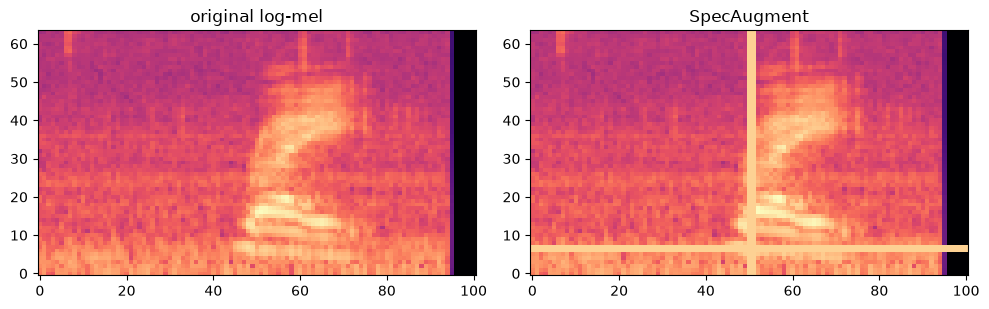

In [2]:
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from kws.data import get_dataloaders

loaders = get_dataloaders("data", batch_size=8, n_mels=64, num_workers=0)
feats, _ = next(iter(loaders["val"]))
spec = feats[0, 0]  # (n_mels, T)

aug = torch.nn.Sequential(T.FrequencyMasking(freq_mask_param=15), T.TimeMasking(time_mask_param=25))
spec_aug = aug(spec.clone().unsqueeze(0)).squeeze(0)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.2))
a1.imshow(spec.numpy(), origin="lower", aspect="auto", cmap="magma"); a1.set_title("original log-mel")
a2.imshow(spec_aug.numpy(), origin="lower", aspect="auto", cmap="magma"); a2.set_title("SpecAugment")
fig.tight_layout(); plt.show()

## 3. 例: 学習率スケジューラ（lr scheduler）

最初は大きめの学習率(lr)で速く学び，後半は小さくして安定させる——というように
**学習の進行に合わせて lr を変える**のがスケジューラ．固定 lr より精度が伸びることが多い．
代表例 **CosineAnnealingLR** は lr をコサイン状に滑らかに 0 へ近づける．

`train.py` は `scheduler: cosine` にすると `CosineAnnealingLR` が有効になる（第3回の布石）．
下で実際の lr の動き方を見てみる．

**PyTorch の各種スケジューラの一覧・グラフ付き解説（研究室まとめ）**:
https://github.com/tenk-9/pytorch_scheduler_list
（StepLR / ExponentialLR / OneCycleLR / ReduceLROnPlateau / WarmRestarts など，挙動の図つき）

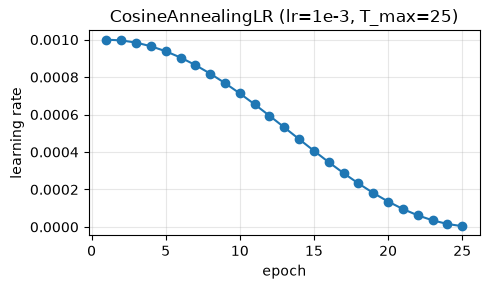

In [3]:
import torch
import matplotlib.pyplot as plt

dummy = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(dummy, T_max=25)
lrs = []
for _ in range(25):
    lrs.append(dummy.param_groups[0]["lr"])
    dummy.step()
    sched.step()

plt.figure(figsize=(5, 3))
plt.plot(range(1, 26), lrs, "o-")
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.title("CosineAnnealingLR (lr=1e-3, T_max=25)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 4. config を増やして実験を切り替える

`train.py` には第5回向けの最小フックがある（`scheduler`, `augment`）．
`configs/baseline.yaml` をコピーして書き換え，`--config` で切り替えれば実験を増やせる．

```bash
cp configs/baseline.yaml configs/cosine.yaml      # scheduler: cosine に
uv run python -m kws.train --config configs/cosine.yaml --device cuda --run-name cosine
uv run python -m kws.evaluate --ckpt exp/cosine/best.pt --device cuda
```

`--run-name` を変えれば `exp/<run_name>/` が分かれるので結果が混ざらない．

## 5. wandb で run を比較する

各実験で `wandb.init(name=...)` の名前を変えれば，ブラウザ上で複数 run の loss/acc 曲線を
重ねて比較できる（簡易 leaderboard）．`train.py` は既に `wandb.log` 済みなので，
`--no-wandb` を付けずに回すだけ．

```bash
uv run python -m kws.train --config configs/cosine.yaml --device cuda --run-name cosine
# → wandb のプロジェクト "kws-tutorial" で baseline と cosine を比較
```

## 6. 進め方（仮説 → 実験 → 考察）

1. **仮説**: 「SpecAugment を入れれば過学習が減って val/test acc が上がるはず」
2. **実験**: `data.py` に augment を組み込み，`configs` を1つ足して学習
3. **比較**: wandb で baseline と並べて曲線・最終 acc を見る
4. **考察**: 効いた/効かない理由を言語化（train-val gap は縮んだ？ どのクラスが改善した？）

1度に複数の変更を入れると何が効いたか分からなくなる．**1施策ずつ**変えるのがコツ．

> （発展・名前だけ）多数の設定を一括で回すなら Hydra の multirun / sweep が便利．

**達成目標**: 自分の工夫で baseline（test acc ≈ 0.92）を超えられたら成功．お疲れさま！